In [1]:
from typing import Optional, Tuple

import numpy as np
from scipy.stats import multivariate_normal, norm

TRACK_HEIGHT = 170
SAMPLING_FREQUENCY = 1500


def simulate_poisson_spikes(rate: np.ndarray, sampling_frequency: float) -> np.ndarray:
    """Given a rate, returns a time series of spikes.
    Parameters
    ----------
    rate : np.ndarray, shape (n_time,)
    sampling_frequency : float
    Returns
    -------
    spikes : np.ndarray, shape (n_time,)
    """
    return np.random.poisson(rate / sampling_frequency)


def simulate_time(n_samples: int, sampling_frequency: float) -> np.ndarray:
    """Generate a time vector given the number of samples and sampling frequency.

    Parameters
    ----------
    n_samples : int
    sampling_frequency : float
        Samples per second.

    Returns
    -------
    time : np.ndarray, shape (n_samples,)
    """
    return np.arange(n_samples) / sampling_frequency


def simulate_position(
    time: np.ndarray, track_height: float, running_speed: float = 10.0
) -> np.ndarray:
    half_height = track_height / 2
    return (
        half_height * np.sin(2 * np.pi * time / running_speed - np.pi / 2) + half_height
    )


def create_place_field(
    place_field_mean: float,
    position: np.ndarray,
    sampling_frequency: float = SAMPLING_FREQUENCY,
    is_condition: Optional[np.ndarray] = None,
    place_field_std_deviation: float = np.sqrt(12.5),
    max_firing_rate: float = 20.0,
    baseline_firing_rate: float = 0.001,
):
    if is_condition is None:
        is_condition = np.ones_like(position, dtype=bool)
    field_firing_rate = norm(place_field_mean, place_field_std_deviation).pdf(position)
    field_firing_rate /= np.nanmax(field_firing_rate)
    field_firing_rate[~is_condition] = 0
    return baseline_firing_rate + max_firing_rate * field_firing_rate


def simulate_place_field_firing_rate(
    means: np.ndarray,
    position: np.ndarray,
    max_rate: float = 15.0,
    variance: float = 12.5,
    is_condition: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Simulates the firing rate of a neuron with a place field at `means`.

    Parameters
    ----------
    means : ndarray, shape (n_position_dims,)
    position : ndarray, shape (n_time, n_position_dims)
    max_rate : float, optional
    variance : float, optional
    is_condition : None or ndarray, (n_time,)

    Returns
    -------
    firing_rate : ndarray, shape (n_time,)
    """
    if is_condition is None:
        is_condition = np.ones(position.shape[0], dtype=bool)
    firing_rate = multivariate_normal(means, variance).pdf(position)
    firing_rate /= firing_rate.max()
    firing_rate *= max_rate
    firing_rate[~is_condition] = 0.0

    return firing_rate


def simulate_neuron_with_place_field(
    means: np.ndarray,
    position: np.ndarray,
    max_rate: float = 15.0,
    variance: float = 12.5,
    sampling_frequency: float = 500.0,
    is_condition: Optional[np.ndarray] = None,
):
    """Simulates the spiking of a neuron with a place field at `means`.

    Parameters
    ----------
    means : ndarray, shape (n_position_dims,)
    position : ndarray, shape (n_time, n_position_dims)
    max_rate : float, optional
    variance : float, optional
    sampling_frequency : float, optional
    is_condition : None or ndarray, (n_time,)

    Returns
    -------
    spikes : ndarray, shape (n_time,)

    """
    firing_rate = simulate_place_field_firing_rate(
        means, position, max_rate, variance, is_condition
    )
    return simulate_poisson_spikes(firing_rate, sampling_frequency)


def get_trajectory_direction(position: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Get the direction of the trajectory.

    Parameters
    ----------
    position : np.ndarray, shape (n_time, n_position_dims)

    Returns
    -------
    direction : np.ndarray, shape (n_time,)
    is_inbound : np.ndarray, shape (n_time,)
    """
    is_inbound = np.insert(np.diff(position) < 0, 0, False)
    return np.where(is_inbound, "Inbound", "Outbound"), is_inbound


def gaussian_pdf(x: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    """Compute the value of a Gaussian probability density function at x with
    given mean and sigma."""
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


def estimate_position_distance(
    place_bin_centers: np.ndarray,
    positions: np.ndarray,
    position_std: np.ndarray,
) -> np.ndarray:
    """Estimates the Euclidean distance between positions and position bins.

    Parameters
    ----------
    place_bin_centers : np.ndarray, shape (n_position_bins, n_position_dims)
    positions : np.ndarray, shape (n_time, n_position_dims)
    position_std : array_like, shape (n_position_dims,)

    Returns
    -------
    position_distance : np.ndarray, shape (n_time, n_position_bins)
    """
    n_time, n_position_dims = positions.shape
    n_position_bins = place_bin_centers.shape[0]

    position_distance = np.ones((n_time, n_position_bins), dtype=np.float32)

    if isinstance(position_std, (int, float)):
        position_std = [position_std] * n_position_dims

    for position_ind, std in enumerate(position_std):
        position_distance *= gaussian_pdf(
            np.expand_dims(place_bin_centers[:, position_ind], axis=0),
            np.expand_dims(positions[:, position_ind], axis=1),
            std,
        )

    return position_distance


def estimate_position_density(
    place_bin_centers: np.ndarray,
    positions: np.ndarray,
    position_std: np.ndarray,
    block_size: int = 100,
    sample_weights: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Estimates a kernel density estimate over position bins using
    Euclidean distances.

    Parameters
    ----------
    place_bin_centers : np.ndarray, shape (n_position_bins, n_position_dims)
    positions : np.ndarray, shape (n_time, n_position_dims)
    position_std : float or array_like, shape (n_position_dims,)
    sample_weights : None or np.ndarray, shape (n_time,)

    Returns
    -------
    position_density : np.ndarray, shape (n_position_bins,)
    """
    n_position_bins = place_bin_centers.shape[0]

    if block_size is None:
        block_size = n_position_bins

    position_density = np.empty((n_position_bins,))
    for start_ind in range(0, n_position_bins, block_size):
        block_inds = slice(start_ind, start_ind + block_size)
        position_density[block_inds] = np.average(
            estimate_position_distance(
                place_bin_centers[block_inds], positions, position_std
            ),
            axis=0,
            weights=sample_weights,
        )
    return position_density


def get_firing_rate(
    is_spike: np.ndarray,
    position: np.ndarray,
    place_bin_centers: np.ndarray,
    is_track_interior: np.ndarray,
    not_nan_position: np.ndarray,
    occupancy: np.ndarray,
    position_std: np.ndarray,
    block_size: int = None,
    weights: np.ndarray = None,
) -> np.ndarray:
    """Estimate the firing rate of a neuron for each position bin.

    Parameters
    ----------
    is_spike : np.ndarray, shape (n_time,)
    position : np.ndarray, shape (n_time, n_position_dims)
    place_bin_centers : np.ndarray, shape (n_position_bins, n_position_dims)
    is_track_interior : np.ndarray, shape (n_position_bins,)
    not_nan_position : np.ndarray, shape (n_time,)
    occupancy : np.ndarray, shape (n_position_bins,)
    position_std : np.ndarray, shape (n_position_dims,
    block_size : int, optional
    weights : np.ndarray, optional

    Returns
    -------
    rate : np.ndarray, shape (n_position_bins,)
    """
    if is_spike.sum() > 0:
        mean_rate = np.average(is_spike, weights=weights)
        marginal_density = np.zeros((place_bin_centers.shape[0],), dtype=np.float32)

        marginal_density[is_track_interior] = estimate_position_density(
            place_bin_centers[is_track_interior],
            np.asarray(
                position[is_spike.astype(bool) & not_nan_position], dtype=np.float32
            ),
            position_std,
            block_size=block_size,
            sample_weights=np.asarray(
                weights[is_spike.astype(bool) & not_nan_position], dtype=np.float32
            ),
        )
        return np.spacing(1) + (mean_rate * marginal_density / occupancy)
    else:
        return np.zeros_like(occupancy)


def simulate_linear_distance_with_pauses(
    time: np.ndarray,
    track_height: float,
    running_speed: float = 10.0,
    pause: float = 0.5,
    sampling_frequency: float = 1.0,
) -> np.ndarray:
    """Simulate linear distance with pauses.

    Parameters
    ----------
    time : np.ndarray, shape (n_time,)
    track_height : float
    running_speed : float, optional
    pause : float, optional
    sampling_frequency : float, optional

    Returns
    -------
    linear_distance : np.ndarray, shape (n_time,)
    """
    linear_distance = simulate_position(time, track_height, running_speed)
    peaks = np.nonzero(linear_distance == track_height)[0]
    n_pause_samples = int(pause * sampling_frequency)
    pause_linear_distance = np.zeros((time.size + n_pause_samples * peaks.size,))
    pause_ind = peaks[:, np.newaxis] + np.arange(n_pause_samples)
    pause_ind += np.arange(peaks.size)[:, np.newaxis] * n_pause_samples

    pause_linear_distance[pause_ind.ravel()] = track_height
    pause_linear_distance[pause_linear_distance == 0] = linear_distance
    return pause_linear_distance[: time.size]


def make_simulated_data(
    track_height: float = TRACK_HEIGHT,
    sampling_frequency: int = SAMPLING_FREQUENCY,
    n_neurons: int = 25,
) -> Tuple[
    np.ndarray, np.ndarray, list[np.ndarray], np.ndarray, np.ndarray, int, np.ndarray
]:
    """Make simulated data for testing.

    Parameters
    ----------
    track_height : float, optional
    sampling_frequency : int, optional
    replay_speed : float, optional
    n_neurons : int, optional

    Returns
    -------
    speed : np.ndarray, shape (n_time,)
    linear_distance : np.ndarray, shape (n_time,)
    spike_times : list[np.ndarray]
    time : np.ndarray, shape (n_time,)
    sampling_frequency : int
    """
    n_samples = sampling_frequency * 65  # 65 seconds

    time = simulate_time(n_samples, sampling_frequency)

    # Simulate position
    linear_distance = (
        simulate_linear_distance_with_pauses(
            time, track_height, sampling_frequency=sampling_frequency, pause=3
        )
        + np.random.randn(*time.shape) * 1e-4
    )

    # Simulate speed
    speed = np.abs(np.diff(linear_distance) / np.diff(time))
    speed = np.insert(speed, 0, 0.0)

    # Simulate spikes
    place_field_means = np.linspace(0, TRACK_HEIGHT, n_neurons)
    place_field_means = place_field_means[place_field_means <= TRACK_HEIGHT]

    place_fields = np.stack(
        [
            create_place_field(place_field_mean, linear_distance, sampling_frequency)
            for place_field_mean in place_field_means
        ]
    )

    spikes = simulate_poisson_spikes(place_fields, sampling_frequency).T

    spike_times = [time[np.nonzero(spike_indicator)[0]] for spike_indicator in spikes.T]

    return (
        speed,
        linear_distance,
        spikes,
        spike_times,
        time,
        sampling_frequency,
        place_fields.T,
    )

In [2]:
(
    speed,
    linear_distance,
    spikes,
    spike_times,
    time,
    sampling_frequency,
    place_fields,
) = make_simulated_data()

Text(0, 0.5, 'Firing Rate [Hz]')

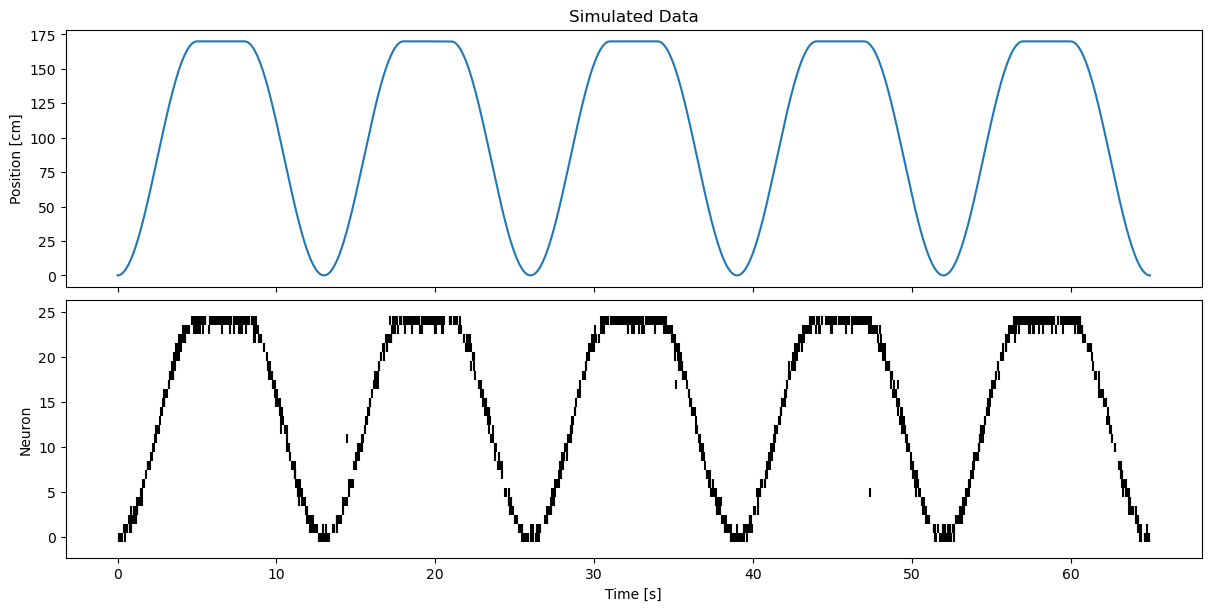

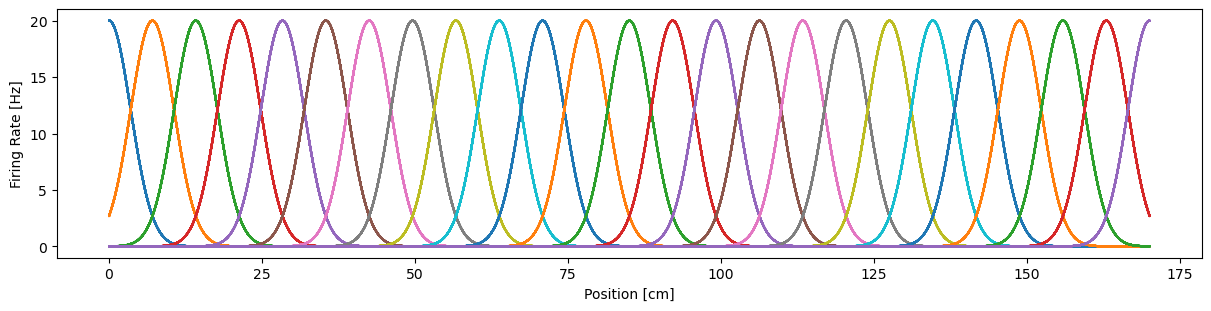

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, constrained_layout=True)
axes[0].plot(time, linear_distance)
axes[0].set_ylabel("Position [cm]")
axes[0].set_title("Simulated Data")
axes[1].eventplot(spike_times, color="black")
axes[1].set_ylabel("Neuron")
axes[1].set_xlabel("Time [s]")

fig, ax = plt.subplots(1, 1, figsize=(12, 3), constrained_layout=True)
ax.plot(linear_distance, place_fields)
ax.set_xlabel("Position [cm]")
ax.set_ylabel("Firing Rate [Hz]")

In [5]:
import jax
import jax.numpy as jnp


from typing import Callable
import jax.scipy.optimize
from functools import partial


def laplace_approximation(f: Callable, x0: jnp.ndarray) -> jnp.ndarray:
    results = jax.scipy.optimize.minimize(fun=lambda x: -f(x), x0=x0, method="BFGS")

    mode = results.x
    covariance = jnp.linalg.pinv(-1.0 * jax.hessian(f)(mode))

    return mode, covariance


def log_pdf(
    x: jnp.ndarray,
    x_prev: jnp.ndarray,
    sig_sq_old: jnp.ndarray,
    spikes: jnp.ndarray,
) -> jnp.ndarray:
    """Log probability density function of the model.

    Parameters
    ----------
    spikes : jnp.ndarray, shape (n_neurons,)

    """
    mu = jnp.exp(1 + x)
    return jnp.squeeze(
        jax.scipy.stats.norm.logpdf(
            x=x,
            loc=x_prev,
            scale=jnp.sqrt(sig_sq_old),
        )
        + jnp.sum(jax.scipy.stats.poisson.logpmf(k=spikes, mu=mu))
    )


place_fields

array([[2.00010000e+01, 2.68915967e+00, 7.52633053e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       [2.00010000e+01, 2.68925358e+00, 7.52678655e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       [2.00010000e+01, 2.68897099e+00, 7.52541444e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       ...,
       [2.00010000e+01, 2.68870729e+00, 7.52413414e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       [2.00010000e+01, 2.68901457e+00, 7.52562603e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       [2.00010000e+01, 2.68913310e+00, 7.52620152e-03, ...,
        1.00000000e-03, 1.00000000e-03, 1.00000000e-03]])

In [ ]:
k = spikes[0]
mu = jnp.ones_like(k)

jnp.sum(jax.scipy.stats.poisson.logpmf(k=k, mu=mu))